In [2]:
import os
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns

# Try to import XGBoost with proper error handling
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError as e:
    print(f"XGBoost import error: {e}")
    print("Mac users: Run 'brew install libomp' to install OpenMP runtime required by XGBoost")
    print("Alternatively, try installing xgboost with: pip install xgboost==1.5.0")
    XGBOOST_AVAILABLE = False

# Import our custom modules
from data_fetcher import CSVDataFetcher
from indicators import TechnicalIndicators

Loading data for AAPL...
Loading data from: data/AAPL_2020-01-01_2023-12-31.csv
Adding technical indicators...
Loaded data with shape: (1006, 27)
Date range: 2020-01-02 00:00:00 to 2023-12-29 00:00:00
Dropped 6 rows with NaN values in avg_return_5

Using thresholds for class separation based on 5-day average returns:
  Sell (0): 5-day avg return < -0.5%
  Hold (1): -0.5% <= 5-day avg return <= 0.5%
  Buy (2): 5-day avg return > 0.5%

Label Distribution Analysis:
Total samples: 1000
Sell labels (0): 199 (19.90%)
Hold labels (1): 493 (49.30%)
Buy labels (2): 308 (30.80%)
Imbalance ratio (max:min): 2.48:1

Return distribution by class:
  Sell (0): mean=-1.07%, min=-3.61%, max=-0.50%
  Hold (1): mean=0.03%, min=-0.49%, max=0.50%
  Buy (2): mean=1.03%, min=0.50%, max=3.50%


/Users/yichizhang/work/python/china-quant/indicators.py:46: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  result = result.fillna(method='bfill').fillna(method='ffill')


<Axes: xlabel='avg_return_5', ylabel='Count'>

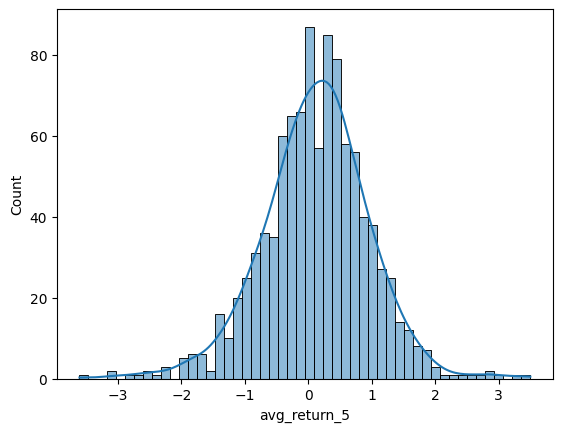

In [5]:
from model.boost_model import BoostModel

model = BoostModel("AAPL", 3)
df = model.load_data()
labeled_df = model.create_labels(df)
sns.histplot(labeled_df['avg_return_5'], kde=True, bins=50)